In [60]:
# import libraries
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
# load dataset
df = pd.read_csv("country_budget_profiles.csv")

In [61]:
feature_columns = joblib.load("feature_columns.pkl")
scaler = joblib.load("scaler.pkl")

In [63]:
X = df[feature_columns]
X_scaled = scaler.transform(X)

In [3]:
# see first 5 rows of dataset
df.head()

,Country,Year,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Total_Budget_Billions_USD,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,...,Administration_and_Others_Percentage,Defense_Amount_Billions_USD,Education_Amount_Billions_USD,Health_Amount_Billions_USD,Interest_Payments_Amount_Billions_USD,Infrastructure_Amount_Billions_USD,Agriculture_Amount_Billions_USD,State_Transfers_Amount_Billions_USD,Social_Welfare_Amount_Billions_USD,Administration_and_Others_Amount_Billions_USD
0,Argentina,1946,5.78,15.4,17.82,8.65,1.552,13.09,7.85,10.47,...,10.47,0.090,0.239,0.276,0.134,0.203,0.122,0.162,0.162,0.162
1,Argentina,1947,5.78,15.4,17.82,8.65,1.629,13.09,7.85,10.47,...,10.47,0.094,0.251,0.290,0.141,0.213,0.128,0.171,0.171,0.171
2,Argentina,1948,5.78,15.4,17.82,8.65,1.711,13.09,7.85,10.47,...,10.47,0.099,0.263,0.305,0.148,0.224,0.134,0.179,0.179,0.179
3,Argentina,1949,5.78,15.4,17.82,8.65,1.796,13.09,7.85,10.47,...,10.47,0.104,0.277,0.320,0.155,0.235,0.141,0.188,0.188,0.188
4,Argentina,1950,5.78,15.4,17.82,8.65,1.886,13.09,7.85,10.47,...,10.47,0.109,0.290,0.336,0.163,0.247,0.148,0.197,0.197,0.197


In [64]:
# check data shape
df.shape

(45, 12)

In [65]:
# get info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               45 non-null     object 
 1   Defense_Percentage                    45 non-null     float64
 2   Education_Percentage                  45 non-null     float64
 3   Health_Percentage                     45 non-null     float64
 4   Interest_Payments_Percentage          45 non-null     float64
 5   Infrastructure_Percentage             45 non-null     float64
 6   Agriculture_Percentage                45 non-null     float64
 7   State_Transfers_Percentage            45 non-null     float64
 8   Social_Welfare_Percentage             45 non-null     float64
 9   Administration_and_Others_Percentage  45 non-null     float64
 10  Cluster                               45 non-null     int64  
 11  Cluster_Name         

In [66]:
# descriptive statistics
df.describe()

,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,Administration_and_Others_Percentage,Cluster
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.00000
mean,9.676664,12.779619,10.311218,8.319500,13.405677,7.233734,11.111849,14.223966,12.939306,3.20000
std,6.653247,3.869941,4.305982,5.713024,4.114029,2.168559,2.434489,6.237248,2.506723,2.29228
min,1.861481,5.000000,2.975185,0.133457,7.528571,2.022840,5.340000,5.340000,6.993333,0.00000
25%,4.407778,9.926173,6.764938,5.000000,9.959506,6.031111,9.050617,8.760864,11.483333,1.00000
50%,8.722099,13.377692,9.667407,7.552716,13.252963,7.265926,11.080617,11.768889,12.986296,3.00000
75%,12.584321,15.240370,13.294074,10.718519,16.773704,8.581235,12.986296,20.718395,14.298025,6.00000
max,31.925185,20.309012,17.384176,32.285679,24.367531,12.183827,16.773704,26.124568,20.302346,6.00000


In [67]:
# check null values
df.isnull().sum()

,0
Country,0
Defense_Percentage,0
Education_Percentage,0
Health_Percentage,0
Interest_Payments_Percentage,0
Infrastructure_Percentage,0
Agriculture_Percentage,0
State_Transfers_Percentage,0
Social_Welfare_Percentage,0
Administration_and_Others_Percentage,0


In [68]:
# select features
features = ['Defense_Percentage',
'Education_Percentage',
'Health_Percentage',
'Interest_Payments_Percentage',
'Infrastructure_Percentage',
'Agriculture_Percentage',
'State_Transfers_Percentage',
'Social_Welfare_Percentage',
'Administration_and_Others_Percentage'
]
x = df[features]

x.head()

,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,Administration_and_Others_Percentage
0,4.640370,15.038395,17.303951,10.010247,13.252963,7.949630,10.601358,10.601358,10.601358
1,6.252716,12.901358,15.528889,5.000000,9.049259,6.031111,12.062346,21.111358,12.062346
2,10.190370,9.926173,4.721975,19.172716,16.794074,8.397531,8.397531,8.397531,13.997531
3,15.000000,5.000000,5.000000,5.000000,21.000000,10.500000,10.500000,10.500000,17.500000
4,15.000000,5.000000,15.799136,5.000000,8.882346,5.920988,11.842716,20.718395,11.842716


In [69]:
# import feature scaler

from sklearn.preprocessing import StandardScaler

In [70]:
# create variable of scaling

scaler = StandardScaler()

In [71]:
# scale features

x_scaled = scaler.fit_transform(x)

In [72]:
# check first 5 data points of scaled features

x_scaled[:5]

array([[-0.76552143,  0.59026722,  1.642308  ,  0.2992902 , -0.03753973,
         0.33385553, -0.21206084, -0.58736526, -0.94321004],
       [-0.52044336,  0.031813  ,  1.2254183 , -0.5876064 , -1.07088301,
        -0.56083882,  0.39484135,  1.11671343, -0.35379649],
       [ 0.07808383, -0.74566755, -1.31268553,  1.92119885,  0.83292679,
         0.54273269, -1.12754259, -0.94469113,  0.42692493],
       [ 0.8091521 , -2.03298358, -1.24738886, -0.5876064 ,  1.86681634,
         1.52321177, -0.25416551, -0.60379933,  1.83994355],
       [ 0.8091521 , -2.03298358,  1.28888829, -0.5876064 , -1.11191327,
        -0.61219451,  0.30360601,  1.05299889, -0.44240277]])

In [73]:
# check first 10 data points of scaled features

df.head(10)

,Country,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,Administration_and_Others_Percentage,Cluster,Cluster_Name
0,Argentina,4.640370,15.038395,17.303951,10.010247,13.252963,7.949630,10.601358,10.601358,10.601358,0,Balanced Public Services
1,Australia,6.252716,12.901358,15.528889,5.000000,9.049259,6.031111,12.062346,21.111358,12.062346,6,Welfare & Healthcare
2,Bangladesh,10.190370,9.926173,4.721975,19.172716,16.794074,8.397531,8.397531,8.397531,13.997531,2,Developing Economy
3,Brazil,15.000000,5.000000,5.000000,5.000000,21.000000,10.500000,10.500000,10.500000,17.500000,5,Infrastructure-Intensive
4,Canada,15.000000,5.000000,15.799136,5.000000,8.882346,5.920988,11.842716,20.718395,11.842716,6,Welfare & Healthcare
5,Chile,12.584321,15.240370,12.456914,4.318765,13.850123,8.311852,11.080617,11.080617,11.080617,0,Balanced Public Services
6,China,11.236364,11.190260,6.948052,5.000000,19.687403,9.843506,9.843506,9.843506,16.409610,5,Infrastructure-Intensive
7,Colombia,10.801605,15.695802,15.455802,14.556173,10.872469,6.525679,8.699012,8.699012,8.699012,0,Balanced Public Services
8,Egypt,8.563580,14.199753,6.270370,12.565556,17.517531,8.760864,8.760864,8.760864,14.600000,2,Developing Economy
9,France,4.878025,10.479383,5.000000,5.000000,11.197531,7.463457,14.926790,26.124568,14.926790,3,Social Welfare Focused


In [74]:
# Make country wise clusters

country_data = df.groupby("Country")[features].mean()
country_data.head()

,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,Administration_and_Others_Percentage
Country,,,,,,,,,
Argentina,4.640370,15.038395,17.303951,10.010247,13.252963,7.949630,10.601358,10.601358,10.601358
Australia,6.252716,12.901358,15.528889,5.000000,9.049259,6.031111,12.062346,21.111358,12.062346
Bangladesh,10.190370,9.926173,4.721975,19.172716,16.794074,8.397531,8.397531,8.397531,13.997531
Brazil,15.000000,5.000000,5.000000,5.000000,21.000000,10.500000,10.500000,10.500000,17.500000
Canada,15.000000,5.000000,15.799136,5.000000,8.882346,5.920988,11.842716,20.718395,11.842716


In [75]:
# check shape of country wise clusters
country_data.shape

(45, 9)

In [76]:
# scale dataset

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(country_data)

In [77]:
# import KMeans algorithm

from sklearn.cluster import KMeans

In [78]:
# create an empty list for within clusters sum of square

wcss = []

In [79]:
# build the loop

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

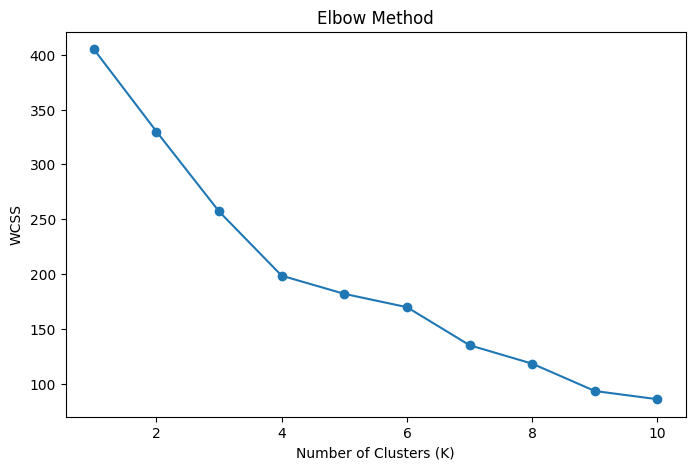

In [80]:
# plot the Elbow Curve

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [81]:
# create clusters

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(x_scaled)

In [82]:
# create cluster column
country_data["Cluster"] = clusters

In [83]:
# check Cluster Column
country_data.head(10)

,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,Administration_and_Others_Percentage,Cluster
Country,,,,,,,,,,
Argentina,4.640370,15.038395,17.303951,10.010247,13.252963,7.949630,10.601358,10.601358,10.601358,0
Australia,6.252716,12.901358,15.528889,5.000000,9.049259,6.031111,12.062346,21.111358,12.062346,3
Bangladesh,10.190370,9.926173,4.721975,19.172716,16.794074,8.397531,8.397531,8.397531,13.997531,2
Brazil,15.000000,5.000000,5.000000,5.000000,21.000000,10.500000,10.500000,10.500000,17.500000,1
Canada,15.000000,5.000000,15.799136,5.000000,8.882346,5.920988,11.842716,20.718395,11.842716,3
Chile,12.584321,15.240370,12.456914,4.318765,13.850123,8.311852,11.080617,11.080617,11.080617,0
China,11.236364,11.190260,6.948052,5.000000,19.687403,9.843506,9.843506,9.843506,16.409610,1
Colombia,10.801605,15.695802,15.455802,14.556173,10.872469,6.525679,8.699012,8.699012,8.699012,0
Egypt,8.563580,14.199753,6.270370,12.565556,17.517531,8.760864,8.760864,8.760864,14.600000,2


In [84]:
# See cluster summary
cluster_summary = country_data.groupby("Cluster").mean()
cluster_summary

,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,Administration_and_Others_Percentage
Cluster,,,,,,,,,
0,14.436532,15.645660,11.847282,10.640499,11.563450,6.046296,9.744762,10.009605,10.067893
1,11.146303,9.336252,6.061493,5.205772,19.216299,10.238628,11.497143,11.497143,15.803785
2,8.059652,15.323855,8.010848,12.920134,16.377613,8.352730,8.680055,8.680055,13.594273
3,6.761220,11.198582,12.535009,5.847331,10.289917,5.995598,13.102541,21.169128,13.102541


In [85]:
# Evaluate cluster quality

from sklearn.metrics import silhouette_score
score = silhouette_score(x_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.24207956430913516


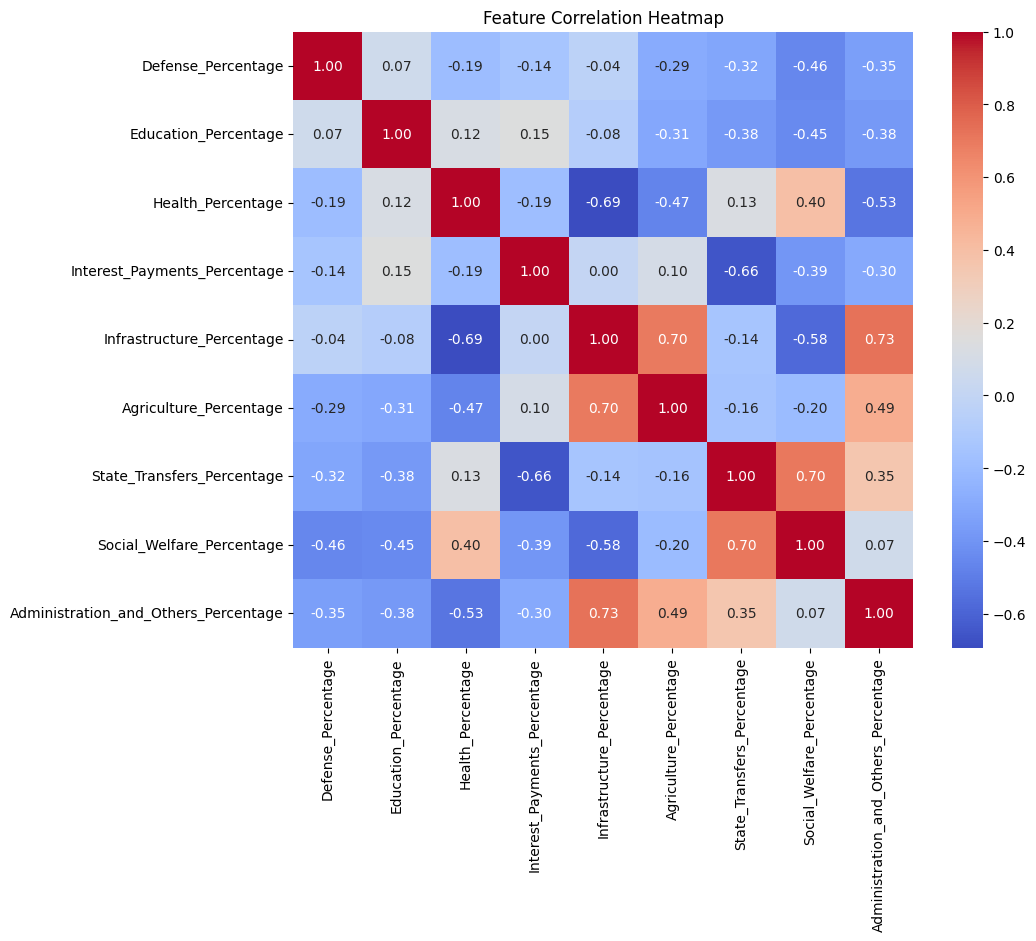

In [86]:
# plot clusters
plt.figure(figsize=(10,8))
sns.heatmap(country_data.drop(columns="Cluster").corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()

In [87]:
# loop to check clusters once again

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    print(k, score)

2 0.15634443315924193
3 0.17636089532390004
4 0.24207956430913516
5 0.1898194266305586
6 0.18212730475721747
7 0.25883622709386755


In [88]:
# ==========================================
# Experiment 2: Add Total Budget as a Feature
# ==========================================

In [121]:
# The df variable from the beginning of the notebook already contains the necessary columns for Experiment 2.

In [122]:
features = [
    'Defense_Percentage',
    'Education_Percentage',
    'Health_Percentage',
    'Interest_Payments_Percentage',
    'Infrastructure_Percentage',
    'Agriculture_Percentage',
    'State_Transfers_Percentage',
    'Social_Welfare_Percentage',
    'Administration_and_Others_Percentage'
]

In [118]:
print(df.columns.tolist())

['Country', 'Defense_Percentage', 'Education_Percentage', 'Health_Percentage', 'Interest_Payments_Percentage', 'Infrastructure_Percentage', 'Agriculture_Percentage', 'State_Transfers_Percentage', 'Social_Welfare_Percentage', 'Administration_and_Others_Percentage', 'Cluster', 'Cluster_Name']


In [119]:
print(features)

['Defense_Percentage', 'Education_Percentage', 'Health_Percentage', 'Interest_Payments_Percentage', 'Infrastructure_Percentage', 'Agriculture_Percentage', 'State_Transfers_Percentage', 'Social_Welfare_Percentage', 'Administration_and_Others_Percentage']


In [123]:
features = [
    'Defense_Percentage',
    'Education_Percentage',
    'Health_Percentage',
    'Interest_Payments_Percentage',
    'Infrastructure_Percentage',
    'Agriculture_Percentage',
    'State_Transfers_Percentage',
    'Social_Welfare_Percentage',
    'Administration_and_Others_Percentage'
]

# recreate country averages
country_data = df.groupby("Country")[features].mean()

In [91]:
# scaling new features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(country_data)

In [92]:
# run the loop

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, clusters)
    print(k, round(score, 4))

2 0.2027
3 0.3191
4 0.2233
5 0.2227
6 0.2671
7 0.2639


In [93]:
# importing PCA from Sklearn

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

In [124]:
from sklearn.decomposition import PCA
import joblib

# Ensure X_scaled has 9 features as defined in feature_columns
# Assuming X_scaled is correctly generated from X = df[feature_columns] and a scaler.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

joblib.dump(pca, "pca.pkl")

print("PCA expects:", pca.n_features_in_)

PCA expects: 9


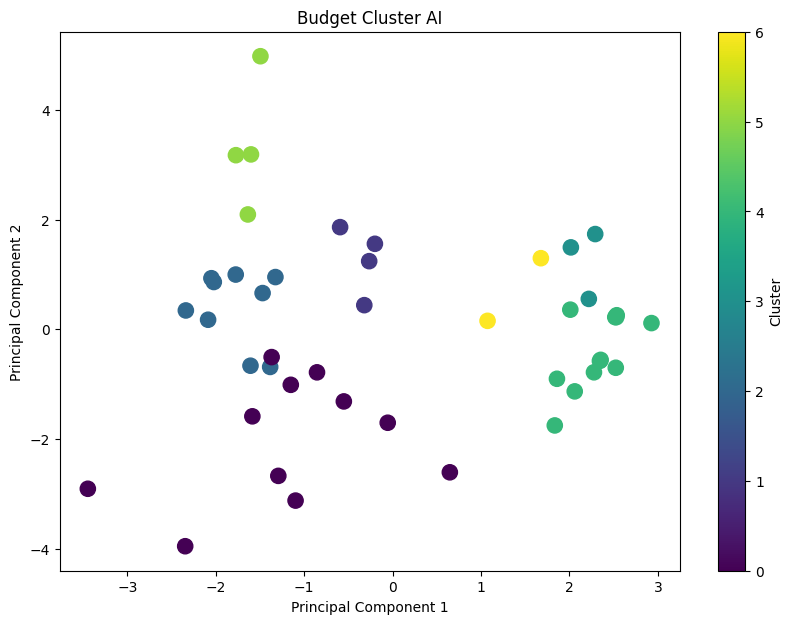

In [95]:
# plot clusters

plt.figure(figsize=(10,7))

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=120
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Budget Cluster AI")

plt.colorbar(label="Cluster")

plt.show()

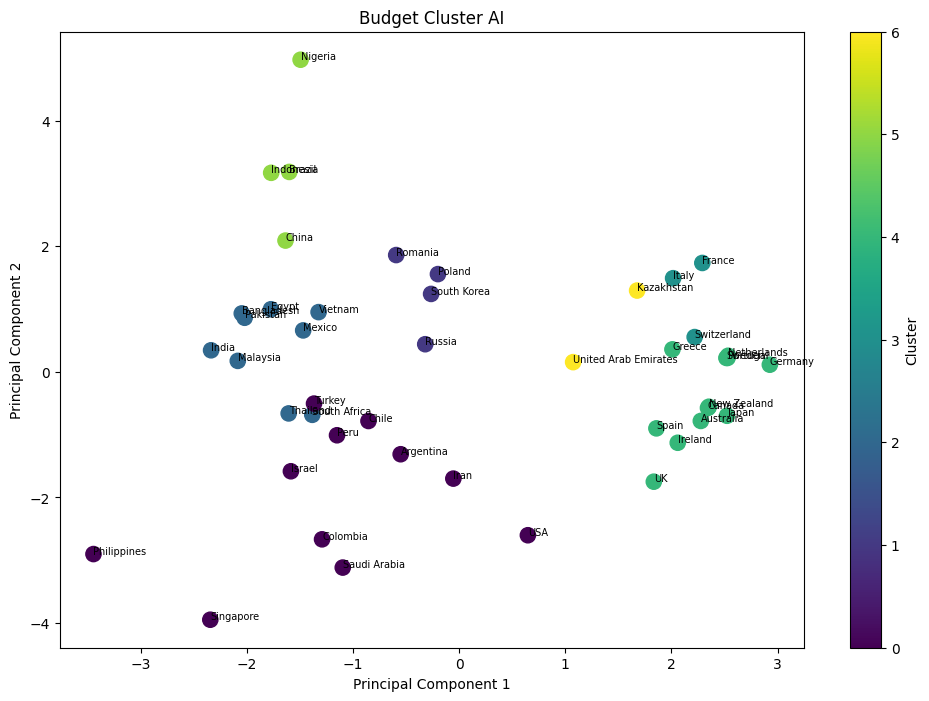

In [96]:
# Principal component analysis

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(12,8))

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=clusters,
    cmap='viridis',
    s=120
)

# Add country names
for i, country in enumerate(country_data.index):
    plt.text(
        x_pca[i,0],
        x_pca[i,1],
        country,
        fontsize=7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Budget Cluster AI")
plt.colorbar(label="Cluster")

plt.show()

In [97]:
# correcting again

features = [
    "Defense_Percentage",
    "Education_Percentage",
    "Health_Percentage",
    "Interest_Payments_Percentage",
    "Infrastructure_Percentage",
    "Agriculture_Percentage",
    "State_Transfers_Percentage",
    "Social_Welfare_Percentage",
    "Administration_and_Others_Percentage"
]

country_data = df.groupby("Country")[features].mean()

In [98]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(country_data)

In [99]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=7, random_state=42)
clusters = kmeans.fit_predict(x_scaled)

In [100]:
country_data["Cluster"] = clusters

In [101]:
for i in sorted(country_data["Cluster"].unique()):
    print(f"\n========== Cluster {i} ==========")
    print(country_data[country_data["Cluster"] == i].index.tolist())


========== Cluster 0 ==========
['Argentina', 'Chile', 'Colombia', 'Israel', 'Peru', 'Philippines', 'Singapore', 'Turkey']

========== Cluster 1 ==========
['Poland', 'Romania', 'Russia', 'South Korea']

========== Cluster 2 ==========
['Bangladesh', 'Egypt', 'India', 'Malaysia', 'Mexico', 'Pakistan', 'South Africa', 'Thailand', 'Vietnam']

========== Cluster 3 ==========
['France', 'Italy', 'Kazakhstan', 'Switzerland']

========== Cluster 4 ==========
['Iran', 'Saudi Arabia', 'United Arab Emirates']

========== Cluster 5 ==========
['Brazil', 'China', 'Indonesia', 'Nigeria']

========== Cluster 6 ==========
['Australia', 'Canada', 'Germany', 'Greece', 'Ireland', 'Japan', 'Netherlands', 'New Zealand', 'Portugal', 'Spain', 'Sweden', 'UK', 'USA']


In [102]:
cluster_summary = country_data.groupby("Cluster").mean()

cluster_summary


,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,Administration_and_Others_Percentage
Cluster,,,,,,,,,
0,12.887577,15.483287,11.343056,12.896512,12.070278,7.108873,9.255941,9.255941,9.700247
1,9.944132,10.647901,8.363626,5.957253,16.270872,9.764621,13.018131,13.018131,13.018131
2,9.636264,15.240878,7.523674,12.103193,16.648244,8.324335,8.324335,8.324335,13.873752
3,4.327377,12.428148,7.031790,5.571975,12.273981,6.226173,14.966574,22.209506,14.966574
4,21.670947,16.168971,10.149712,1.588765,12.607366,2.521687,12.607366,10.085597,12.607366
5,8.801097,8.211300,4.855501,6.292407,21.552807,10.776525,10.776525,10.776525,17.960612
6,6.793818,10.799412,14.930347,6.632602,9.126638,6.084129,12.169205,21.295268,12.169205


In [103]:
# model evaluation step 1
from sklearn.metrics import calinski_harabasz_score
ch_score = calinski_harabasz_score(x_scaled, clusters)
print("Calinski-Harabasz Index:", round(ch_score, 2))

Calinski-Harabasz Index: 12.65


In [104]:
# model evaluation step 2
from sklearn.metrics import davies_bouldin_score
db_score = davies_bouldin_score(x_scaled, clusters)
print("Davies-Bouldin Index:", round(db_score, 3))

Davies-Bouldin Index: 1.23


In [105]:
# saving the model
import joblib
joblib.dump(kmeans, "budget_cluster_model.pkl")

['budget_cluster_model.pkl']

In [106]:
# save scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [107]:
# import os

import os
print(os.listdir())

['.config', 'scaler.pkl', 'budget_cluster_model.pkl', 'cluster_names.pkl', 'country_budget_profiles.csv', 'Global_Budget.csv', 'feature_columns.pkl', 'pca.pkl', 'sample_data']


In [108]:
# save features names

feature_columns = [
    "Defense_Percentage",
    "Education_Percentage",
    "Health_Percentage",
    "Interest_Payments_Percentage",
    "Infrastructure_Percentage",
    "Agriculture_Percentage",
    "State_Transfers_Percentage",
    "Social_Welfare_Percentage",
    "Administration_and_Others_Percentage"
]

joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [110]:
# save cluster names

cluster_names = {
    0: "Balanced Public Services",
    1: "Infrastructure & Development",
    2: "Developing Economy",
    3: "Social Welfare Focused",
    4: "Defense Priority",
    5: "Infrastructure-Intensive",
    6: "Welfare & Healthcare"
}

joblib.dump(cluster_names, "cluster_names.pkl")

['cluster_names.pkl']

In [111]:
# verifying that files are saved

for file in os.listdir():
    if file.endswith(".pkl"):
        print(file)

scaler.pkl
budget_cluster_model.pkl
cluster_names.pkl
feature_columns.pkl
pca.pkl


In [112]:
# modifying and saving the csv as per app requirement

country_data["Cluster_Name"] = country_data["Cluster"].map(cluster_names)
country_data.head()

,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,Administration_and_Others_Percentage,Cluster,Cluster_Name
Country,,,,,,,,,,,
Argentina,4.640370,15.038395,17.303951,10.010247,13.252963,7.949630,10.601358,10.601358,10.601358,0,Balanced Public Services
Australia,6.252716,12.901358,15.528889,5.000000,9.049259,6.031111,12.062346,21.111358,12.062346,6,Welfare & Healthcare
Bangladesh,10.190370,9.926173,4.721975,19.172716,16.794074,8.397531,8.397531,8.397531,13.997531,2,Developing Economy
Brazil,15.000000,5.000000,5.000000,5.000000,21.000000,10.500000,10.500000,10.500000,17.500000,5,Infrastructure-Intensive
Canada,15.000000,5.000000,15.799136,5.000000,8.882346,5.920988,11.842716,20.718395,11.842716,6,Welfare & Healthcare


In [113]:
# save modified file

country_data.to_csv("country_budget_profiles.csv")

In [114]:
# save PCA model

joblib.dump(pca, "pca.pkl")

['pca.pkl']

In [115]:
# verify saved files

for file in os.listdir():
    if file.endswith(".pkl"):
        print(file)

scaler.pkl
budget_cluster_model.pkl
cluster_names.pkl
feature_columns.pkl
pca.pkl


In [125]:
import joblib

# Reload feature_columns to ensure consistency
feature_columns = joblib.load("feature_columns.pkl")
print(feature_columns)
print(len(feature_columns))

# Explicitly load the pca model from the saved file
loaded_pca = joblib.load("pca.pkl")
print(loaded_pca.n_features_in_)

['Defense_Percentage', 'Education_Percentage', 'Health_Percentage', 'Interest_Payments_Percentage', 'Infrastructure_Percentage', 'Agriculture_Percentage', 'State_Transfers_Percentage', 'Social_Welfare_Percentage', 'Administration_and_Others_Percentage']
9
9
